###==========================================
###1. IMPORT LIBRARIES
###==========================================

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Setting a professional visual theme

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

### ==========================================
### 2. DATA LOADING & INITIAL LOOK
### ==========================================

In [3]:
df = pd.read_csv("/content/hotel_bookings.csv")

Insight: Understanding the scale. 119k rows ensures our
statistical analysis is robust and not due to small sample bias.

Initial overview of the dataset that helps verify that the data has been loaded correctly.

In [4]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (119390, 32)


### ==========================================
### 3. DATA CLEANING (LOCKSTEP WITH TEAM)
### ==========================================

In [5]:
# Children replace with 0
df['children'] = df['children'].fillna(0)

In [6]:
# Country replace with 'Unknown'
df['country'] = df['country'].fillna("Unknown")

In [7]:
# Dropping agent & company (too many missing values)
df.drop(["agent", "company"], axis=1, inplace=True, errors="ignore")

In [8]:
# Convert date to datetime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

Insight: Cleaned data preserves integrity for Tableau while
ensuring Python numerical operations don't crash on NaNs.

### ==========================================
### 4. FEATURE ENGINEERING
### ==========================================

In [9]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['revenue'] = df['adr'] * df['total_stay']

### ==========================================
### 5. EXPLORATORY DATA ANALYSIS (EDA)
### ==========================================

**A. Overall Cancellation Rate**

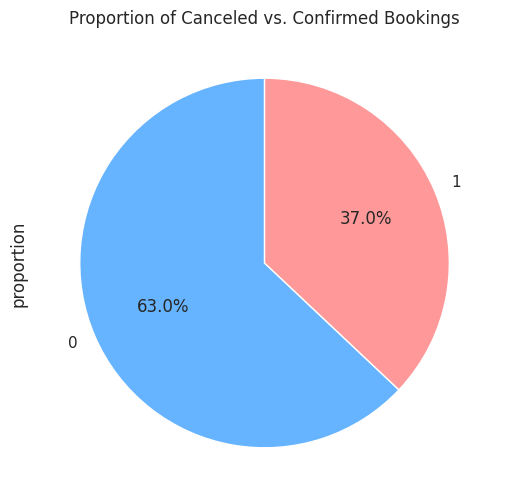

In [10]:
plt.figure()
df['is_canceled'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Proportion of Canceled vs. Confirmed Bookings')
plt.show()

Insight: A 37% cancellation rate is high for the industry,
suggesting a need for better deposit policies.

**B. Hotel Type vs Cancellation**

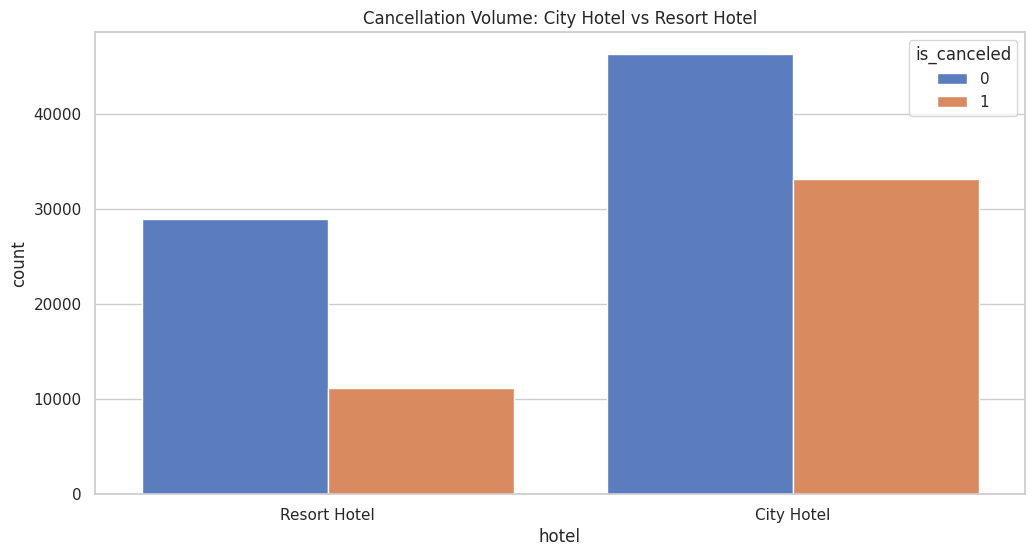

In [11]:
plt.figure()
sns.countplot(data=df, x='hotel', hue='is_canceled')
plt.title('Cancellation Volume: City Hotel vs Resort Hotel')
plt.show()

Insight: City hotels face significantly higher cancellation volumes,
likely due to the "transient" nature of business travel.

**C. Lead Time Deep Dive**

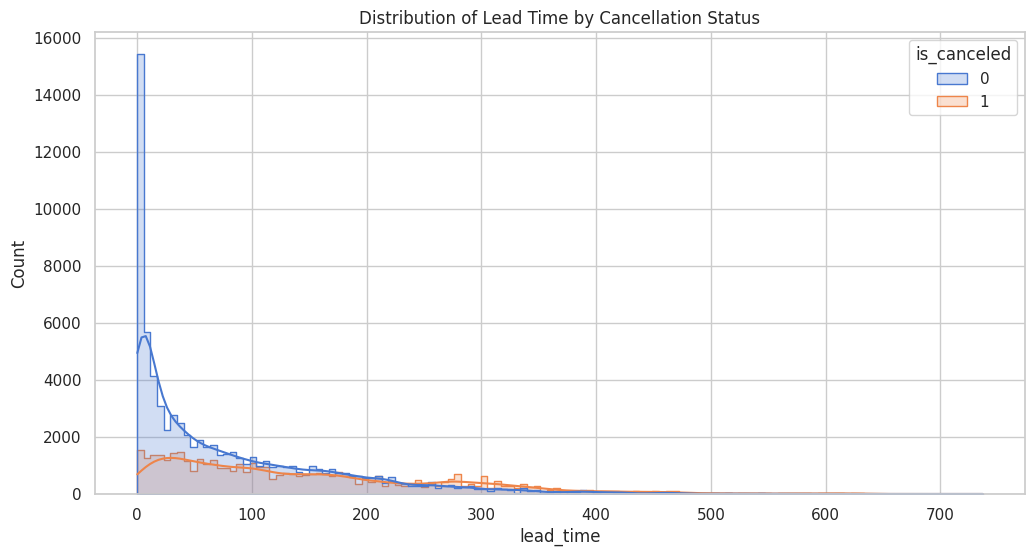

In [12]:
plt.figure()
sns.histplot(data=df, x='lead_time', hue='is_canceled', kde=True, element="step")
plt.title('Distribution of Lead Time by Cancellation Status')
plt.show()

Insight: The "Danger Zone" is bookings made 100+ days in advance. The further out a guest books, the more likely they are to cancel.

**D. Market Segment Risk Analysis (New & High Impact)**

<Figure size 1200x600 with 0 Axes>

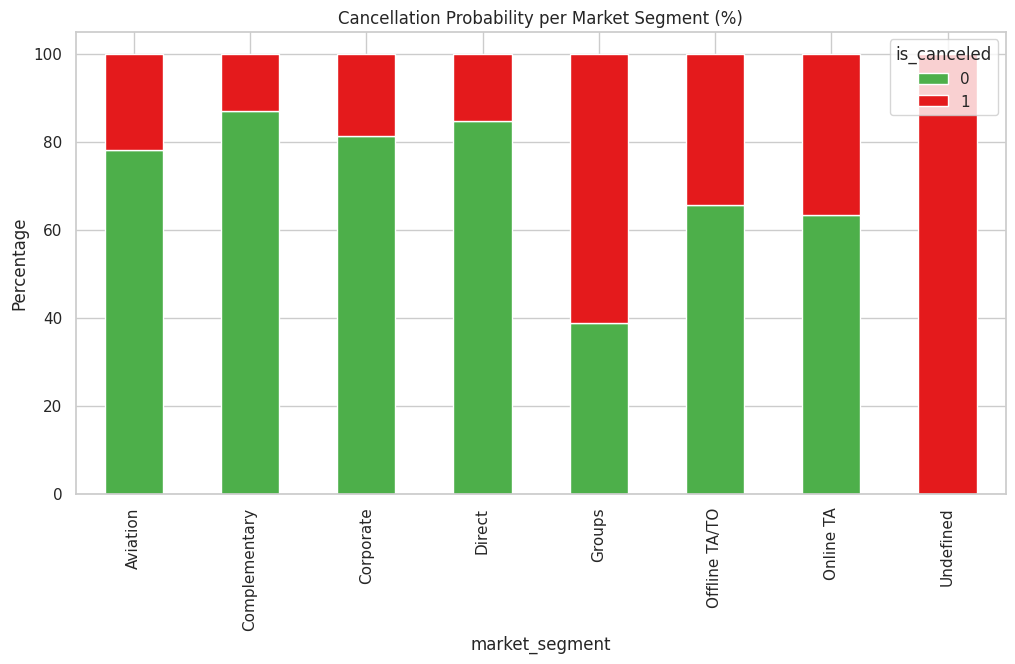

In [13]:
plt.figure()
market_cancel = pd.crosstab(df['market_segment'], df['is_canceled'], normalize='index') * 100
market_cancel.plot(kind='bar', stacked=True, color=['#4daf4a', '#e41a1c'])
plt.title('Cancellation Probability per Market Segment (%)')
plt.ylabel('Percentage')
plt.show()

Insight: Online Travel Agents (OTA) have the highest volume,
but "Groups" often have the highest percentage risk.

**E. Impact of Special Requests (New & High Impact)**

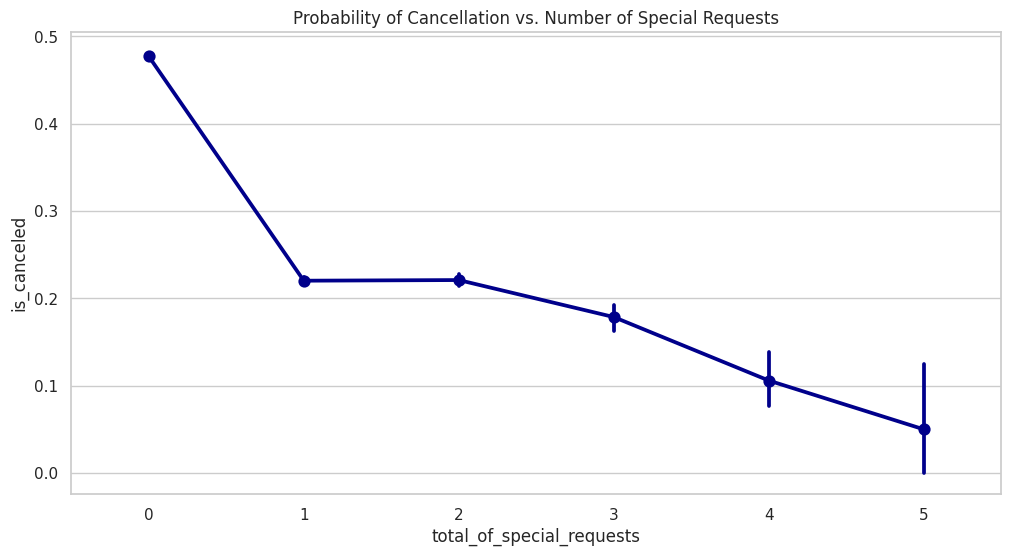

In [14]:
plt.figure()
sns.pointplot(data=df, x='total_of_special_requests', y='is_canceled', color='darkblue')
plt.title('Probability of Cancellation vs. Number of Special Requests')
plt.show()

Insight: This shows a clear inverse relationship. As special requests
increase, cancellation probability drops drastically. Requests = Intent.

**F. Monthly Trends**

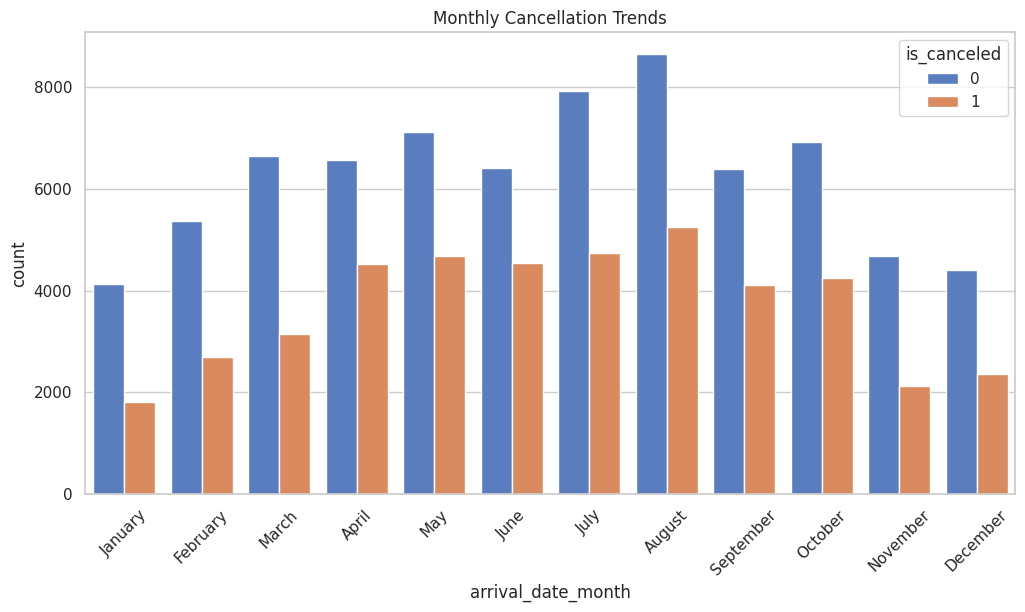

In [15]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
plt.figure()
sns.countplot(data=df, x='arrival_date_month', hue='is_canceled', order=month_order)
plt.xticks(rotation=45)
plt.title('Monthly Cancellation Trends')
plt.show()

Insight: Peak summer months (July/August) see the most activity
and the most cancellations, requiring high-season overbooking strategies.